# GPTNeo Training on TinyStories - L4 Optimized (Fast Training)

Train a GPTNeo decoder-only transformer on TinyStories dataset with L4 GPU optimization.

**Features:**
- 🚀 BFloat16 mixed precision for 2x speedup
- 📚 30K TinyStories samples (fast training)
- 🎯 ~10M parameter model (4 layers, optimized for fast iteration)
- ⚡ ~45-60 mins training time on L4
- 📊 Expected PPL: 25-40

**Setup:**
1. Runtime → Change runtime type → L4 GPU
2. Run all cells
3. Training starts automatically

**Paper:** Eldan, R., & Li, Y. (2023). TinyStories: How Small Can Language Models Be and Still Speak Coherent English? arXiv:2305.07759.

## 1. Setup & Installation

In [1]:
# Check GPU
!nvidia-smi

import torch
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"BFloat16 supported: {torch.cuda.is_bf16_supported()}")

Wed Nov 12 06:33:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   67C    P8             15W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install dependencies
!pip install -q transformers datasets tqdm tensorboard

print("✓ Dependencies installed")

✓ Dependencies installed


In [3]:
# Cell 4: Clone repository and install package
import os

# Remove existing repository if it exists
if os.path.exists('PROJECT'):
    !rm -rf PROJECT
    print("✓ Existing repository removed")

# Clone repository
!git clone https://gitlab.cim.rhul.ac.uk/wmis066/PROJECT.git
print("✓ Repository cloned")

# Change to project directory
%cd PROJECT

Cloning into 'PROJECT'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 82 (delta 21), reused 0 (delta 0), pack-reused 3 (from 1)
Receiving objects: 100% (82/82), 424.00 KiB | 782.00 KiB/s, done.
Resolving deltas: 100% (21/21), done.
✓ Repository cloned
/content/PROJECT


In [4]:
import sys
import os
import importlib
import shutil

# Clear all Python cache to avoid autocast compatibility issues
print("Clearing Python cache...")

# Remove cached modules
modules_to_remove = [m for m in list(sys.modules.keys())
                     if any(x in m for x in ['mha', 'train', 'transformer', 'data_loader', 'attention', 'layers'])]
for module in modules_to_remove:
    del sys.modules[module]

print(f"✓ Removed {len(modules_to_remove)} cached modules")

# Clear __pycache__ directories
cache_dirs = [
    '/content/PROJECT/AttentionHeads/mha/__pycache__',
    '/content/PROJECT/AttentionHeads/__pycache__',
]
for cache_dir in cache_dirs:
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
        print(f"✓ Cleared {cache_dir}")

# Add to path
project_root = '/content/PROJECT'
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"✓ Added {project_root} to sys.path")

# Import fresh modules
print("\nImporting modules with fixed autocast...")
from AttentionHeads.mha import transformer
from AttentionHeads.mha import data_loader
from AttentionHeads.mha import train

# Reload to ensure absolutely fresh code
importlib.reload(transformer)
importlib.reload(data_loader)
importlib.reload(train)

# Create aliases
GPTNeoForCausalLM = transformer.GPTNeoForCausalLM
create_gptneo_model = transformer.create_gptneo_model
TinyStoriesDataModule = data_loader.TinyStoriesDataModule
GPTNeoTrainer = train.GPTNeoTrainer

print("✓ Modules loaded with autocast compatibility fix!")
print("✓ Ready to train!")

Clearing Python cache...
✓ Removed 8 cached modules
✓ Added /content/PROJECT to sys.path

Importing modules with fixed autocast...
✓ Modules loaded with autocast compatibility fix!
✓ Ready to train!


## 2. Configuration

In [5]:
# Training configuration
config = {
  "model_name": "gptneo_tinystories",
  "architecture": "gpt_neo_decoder",
  "description": "GPTNeo decoder-only transformer for TinyStories dataset with L4 optimization",

  "model": {
    "vocab_size": 50257,
    "hidden_size": 256,
    "num_layers": 4,
    "num_heads": 8,
    "intermediate_size": 1024,
    "max_position_embeddings": 256,
    "dropout": 0.2,
    "activation": "gelu",
    "layer_norm_epsilon": 1e-5,
    "initializer_range": 0.02,
    "tie_word_embeddings": True
  },

  "training": {
    "dataset": "tinystories",
    "train_samples": 30000,
    "val_samples": 5000,
    "batch_size": 64,
    "gradient_accumulation_steps": 4,
    "effective_batch_size": 256,
    "max_steps": 6000,
    "warmup_steps": 600,
    "learning_rate": 5e-5,
    "min_learning_rate": 1e-6,
    "lr_scheduler": "cosine",
    "weight_decay": 0.01,
    "gradient_clip": 0.5,
    "use_bf16": True,
    "optimizer": "adamw",
    "adam_beta1": 0.9,
    "adam_beta2": 0.999,
    "adam_epsilon": 1e-8,
    "max_seq_length": 256
  },

  "data": {
    "tokenizer": "gpt2",
    "dataset_name": "roneneldan/TinyStories",
    "dataset_config": "default",
    "text_column": "text",
    "streaming": False,
    "num_workers": 4,
    "prefetch_factor": 2,
    "pin_memory": True
  },

  "logging": {
    "log_dir": "../logs/gptneo_tinystories",
    "checkpoint_dir": "../checkpoints/gptneo_tinystories",
    "save_every_steps": 2000,
    "eval_every_steps": 1000,
    "log_every_steps": 50,
    "use_tensorboard": True,
    "use_wandb": False,
    "project_name": "gptneo-tinystories",
    "run_name": "gptneo_256_4l_l4_optimized"
  },

  "evaluation": {
    "eval_batch_size": 32,
    "eval_max_steps": 100,
    "generation_prompts": [
      "Once upon a time",
      "One day, a little girl",
      "In a big forest",
      "There was a happy dog"
    ],
    "generation_max_length": 100,
    "generation_temperature": 0.8,
    "generation_top_k": 50,
    "generation_top_p": 0.95
  },

  "checkpointing": {
      "save_total_limit": 3,
      "save_best_only": False
  },

  "random_seed": 42
}


# Save config
import json
with open('config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✓ Configuration saved")
print(f"\nModel: {config['model']['hidden_size']}d, {config['model']['num_layers']} layers")
print(f"Training: {config['training']['train_samples']:,} samples, {config['training']['max_steps']:,} steps")
print(f"Batch size: {config['training']['batch_size']} (gradient accum: {config['training']['gradient_accumulation_steps']})")
print(f"Effective batch size: {config['training']['effective_batch_size']}")
print(f"Learning rate: {config['training']['learning_rate']}")
print(f"BFloat16: {config['training']['use_bf16']}")

✓ Configuration saved

Model: 256d, 4 layers
Training: 30,000 samples, 6,000 steps
Batch size: 64 (gradient accum: 4)
Effective batch size: 256
Learning rate: 5e-05
BFloat16: True


## 3. Model Architecture

In [6]:

# Create model
model = create_gptneo_model(config['model'])

# Model info
total_params = model.get_num_params()
non_embed_params = model.get_num_params(non_embedding=True)
embed_params = total_params - non_embed_params

print("GPTNeo Model Created")
print("=" * 50)
print(f"Total parameters: {total_params:,}")
print(f"Non-embedding parameters: {non_embed_params:,}")
print(f"Embedding parameters: {embed_params:,}")
print("=" * 50)

# Test forward pass
test_input = torch.randint(0, config['model']['vocab_size'], (2, 128))
test_output = model(test_input)
print(f"\nTest forward pass:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print("✓ Model working correctly")

# Clean up test variables to free memory
del model, test_input, test_output
import gc
gc.collect()
torch.cuda.empty_cache()
print("✓ Test cleanup complete")

GPTNeo Model Created
Total parameters: 16,090,880
Non-embedding parameters: 3,159,552
Embedding parameters: 12,931,328

Test forward pass:
  Input shape: torch.Size([2, 128])
  Output shape: torch.Size([2, 128, 50257])
✓ Model working correctly
✓ Test cleanup complete


## 4. Data Loading

In [7]:

# Create data module
data_cfg = {
    'dataset_name': config['data']['dataset_name'],
    'tokenizer': config['data']['tokenizer'],
    'train_samples': config['training']['train_samples'],
    'val_samples': config['training']['val_samples'],
    'batch_size': config['training']['batch_size'],
    'max_seq_length': config['training']['max_seq_length'],
    'num_workers': config['data']['num_workers'],
    'pin_memory': config['data']['pin_memory']
}

data_module = TinyStoriesDataModule(data_cfg)
data_module.setup()

# Test data loading
train_loader = data_module.train_dataloader()
batch = next(iter(train_loader))

print("\nData Loading Test:")
print(f"  Batch shape: {batch['input_ids'].shape}")
print(f"  Attention mask shape: {batch['attention_mask'].shape}")

# Decode a sample story
sample_ids = batch['input_ids'][0]
mask = batch['attention_mask'][0]
sample_ids = sample_ids[mask == 1]
sample_story = data_module.tokenizer.decode(sample_ids)

print(f"\nSample Story ({len(sample_ids)} tokens):")
print("-" * 50)
print(sample_story[:300] + "...")
print("-" * 50)
print("✓ Data loading working correctly")

# Clean up test variables to free memory
del train_loader, batch, sample_ids, mask, sample_story
import gc
gc.collect()
torch.cuda.empty_cache()
print("✓ Data test cleanup complete")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Sampling 30000 from 2119719 examples...
Dataset size: 30000
Loading TinyStories dataset (split=validation)...
Sampling 5000 from 21990 examples...
Dataset size: 5000

Dataset Summary:
  Train samples: 30,000
  Val samples: 5,000
  Max sequence length: 256
  Batch size: 64
  Vocab size: 50257


Data Loading Test:
  Batch shape: torch.Size([64, 256])
  Attention mask shape: torch.Size([64, 256])

Sample Story (187 tokens):
--------------------------------------------------
Once upon a time, there was a little girl named Lucy. She had a handle in her hand. Lucy wanted to stay put, but she was very curious.

One day, Lucy went for a walk outside. On her way, she passed by a little pond. There were some big fish inside the pond and some little fish too.

She looked all a...
--------------------------------------------------
✓ Data loading working correctly
✓ Data test cleanup complete


## 5. Training Setup

In [8]:

# Create trainer
device = 'cuda' if torch.cuda.is_available() else 'cpu'
trainer = GPTNeoTrainer(config, device=device)

print("✓ Trainer initialized")
print(f"\nTraining Configuration:")
print(f"  Device: {device}")
print(f"  Mixed precision: {'BFloat16' if trainer.use_bf16 else 'FP32'}")
print(f"  Model: ~10M parameters (256d, 4 layers)")
print(f"  Steps: {config['training']['max_steps']:,}")
print(f"  Batch size: {config['training']['batch_size']}")
print(f"  Learning rate: {config['training']['learning_rate']}")
print(f"  Estimated time: ~45-60 mins on L4")

Using device: cuda
Mixed precision: BFloat16

Model Parameters:
  Total: 16,090,880
  Non-embedding: 3,159,552
  Embedding: 12,931,328

Setting up TinyStories datasets...
Loading TinyStories dataset (split=train)...
Sampling 30000 from 2119719 examples...
Dataset size: 30000
Loading TinyStories dataset (split=validation)...
Sampling 5000 from 21990 examples...
Dataset size: 5000

Dataset Summary:
  Train samples: 30,000
  Val samples: 5,000
  Max sequence length: 256
  Batch size: 64
  Vocab size: 50257

✓ Trainer initialized

Training Configuration:
  Device: cuda
  Mixed precision: BFloat16
  Model: ~10M parameters (256d, 4 layers)
  Steps: 6,000
  Batch size: 64
  Learning rate: 5e-05
  Estimated time: ~45-60 mins on L4


## 6. Start Training

**⚠️ This cell will run for ~45-60 minutes on L4 GPU.**

Training will:
- Train for 6,000 steps (fast training)
- Log metrics every 50 steps
- Evaluate every 1,000 steps
- Generate sample stories during evaluation
- Save checkpoints every 2,000 steps
- Save best model based on validation loss

**Model:** ~10M parameters (4 layers, 256d hidden, optimized for fast iteration)
**Dataset:** 30,000 training samples

In [9]:
# Clear GPU memory before training
import gc
import torch

print("Clearing GPU memory...")

# Delete test model and data if they exist
if 'model' in globals():
    del model
if 'test_input' in globals():
    del test_input
if 'test_output' in globals():
    del test_output
if 'batch' in globals():
    del batch
if 'train_loader' in globals():
    del train_loader
if 'data_module' in globals():
    # Keep data_module but clear its cache
    if hasattr(data_module, 'train_dataset'):
        del data_module.train_dataset
    if hasattr(data_module, 'val_dataset'):
        del data_module.val_dataset

# Force garbage collection
gc.collect()

# Clear CUDA cache
torch.cuda.empty_cache()

# Check memory
print(f"GPU Memory allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"GPU Memory reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
print("✓ GPU memory cleared - ready for training")

Clearing GPU memory...
GPU Memory allocated: 0.06 GB
GPU Memory reserved: 0.06 GB
✓ GPU memory cleared - ready for training


In [10]:
# Start training
trainer.train()


Starting training for 6000 steps...
Effective batch size: 256
Gradient accumulation steps: 4


Training:   0%|          | 0/6000 [00:00<?, ?it/s]/content/PROJECT/AttentionHeads/mha/train.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_bf16):
Training:  17%|█▋        | 999/6000 [04:44<23:33,  3.54it/s, loss=4.2120, ppl=67.49, lr=4.93e-05]



Evaluation at step 1000...



Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]/content/PROJECT/AttentionHeads/mha/train.py:247: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_bf16):

Evaluating:  79%|███████▉  | 79/100 [00:07<00:02, 10.41it/s, loss=4.0563]


Val Loss: 4.0563, Val PPL: 57.76

Generating samples...

Prompt: Once upon a time
Generated: Once upon a time, there was a very big, and. He was the time, that the big of the said, " the was a little.



The little day, " to the she. She was a little little. He was a it. But was a big. The th...

Prompt: One day, a little girl
Generated: One day, a little girl. He was a. He was for a big was a friends.






The and a big the big. It was a very. He's a she, "my. They and and happy was a " to the the and, the park. It was the it with t...

Prompt: In a big forest
Generated: In a big forest.

" a big to a big! " he to to his he in. He. So, the he. It.










" the's he was had and a little.













" the the it!

The to. She, the his. She had her the park. He to h...

Prompt: There was a happy dog
Generated: There was a happy dog of was a her play. One.

They the her his the the the boy's it had a She. They to the sad. The,. You was a park the mom to a big,, it to. She a the big.

...

Val Loss: 3.6310, Val PPL: 37.75

Generating samples...

Prompt: Once upon a time
Generated: Once upon a time, there was a little boy named they loved to his mommy. One day,, I see the ground and Lily's mommy was a big. 
Lily's mommy was too, "No, she was to get the big big to the, "That's go...

Prompt: One day, a little girl
Generated: One day, a little girl named Lily.
He ran to the other to be. Lily was so so, "We have to be not know it to see a new girl. They said, "I'm very so happy. Timmy."
One day, Timmy's mommy and said, "I c...

Prompt: In a big forest
Generated: In a big forest. He was, they had a big. The other. He was very happy to eat the tree with him. She went to play for her hands and was very happy, Lily in the park. 


One day, but they wanted to stay...

Prompt: There was a happy dog
Generated: There was a happy dog. Lily was very and he had a little girl loved to play in the little boy was a big of his friends, she tried to the park in the park of the way to make t

Training: 100%|██████████| 6000/6000 [29:21<00:00,  3.41it/s, loss=3.7604, ppl=42.96, lr=1.00e-06]


Checkpoint saved: ../checkpoints/gptneo_tinystories/checkpoint_step_6000.pt


Final evaluation...


Evaluating:  79%|███████▉  | 79/100 [00:07<00:01, 10.55it/s, loss=3.6310]


Final Val Loss: 3.6310, Final Val PPL: 37.75
Checkpoint saved: ../checkpoints/gptneo_tinystories/final_model.pt

✓ Training completed!


## 7. Evaluation & Generation

In [11]:
# Load best model
import torch
from transformers import GPT2Tokenizer

# Load checkpoint (weights_only=False for PyTorch 2.6+ compatibility)
checkpoint_path = '/content/checkpoints/gptneo_tinystories/best_model.pt'
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# Create model and load weights
model = create_gptneo_model(config['model'])
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

print("✓ Best model loaded")
print(f"Training step: {checkpoint['global_step']:,}")
print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
if 'metrics' in checkpoint:
    metrics = checkpoint['metrics']
    print(f"Validation PPL: {metrics.get('val_ppl', 'N/A'):.2f}" if isinstance(metrics.get('val_ppl'), float) else f"Validation PPL: {metrics.get('val_ppl', 'N/A')}")

✓ Best model loaded
Training step: 3,000
Best validation loss: 3.6065
Validation PPL: 36.84


In [12]:
# Generate stories
def generate_story(prompt, max_length=200, temperature=0.8, top_k=50, top_p=0.95):
    """Generate a story from a prompt"""
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_length=max_length,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p
        )

    story = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return story

# Test prompts
prompts = [
    "Once upon a time",
    "One day, a little girl",
    "In a big forest",
    "There was a happy dog",
    "A small boy found"
]

print("\nGenerated Stories:")
print("=" * 80)

for i, prompt in enumerate(prompts, 1):
    story = generate_story(prompt, max_length=150, temperature=0.8)
    print(f"\n{i}. Prompt: \"{prompt}\"")
    print("-" * 80)
    print(story)
    print("-" * 80)


Generated Stories:

1. Prompt: "Once upon a time"
--------------------------------------------------------------------------------
Once upon a time, there was a little girl named Timmy. They loved to play at the ground and took his mommy wanted to the other and went to do and it was very happy and could find the park. One day, but he was so happy.
One day, "It's mom said, "Yes, "I have a big, but she's mommy. But Lily's mommy and was so happy and tried to his mommy. It was scared and, "Okay, he heard a big friend, "Don't see his mom. 




"Thank you not like to be fun.






The little girl had to the big, they saw his mom
--------------------------------------------------------------------------------

2. Prompt: "One day, a little girl"
--------------------------------------------------------------------------------
One day, a little girl named Timmy. She loved to the park with a lot and played on her mommy ran, but he could do the ground. She would play. She asked a. It was so exci

In [13]:
# Interactive generation
print("\nInteractive Story Generation")
print("=" * 80)
print("Enter your own prompts to generate stories!\n")

while True:
    prompt = input("Enter prompt (or 'quit' to exit): ")
    if prompt.lower() in ['quit', 'exit', 'q']:
        break

    if not prompt.strip():
        continue

    story = generate_story(prompt, max_length=200, temperature=0.8)
    print("\nGenerated Story:")
    print("-" * 80)
    print(story)
    print("-" * 80 + "\n")


Interactive Story Generation
Enter your own prompts to generate stories!

Enter prompt (or 'quit' to exit): quit


## 8. Analyze Results

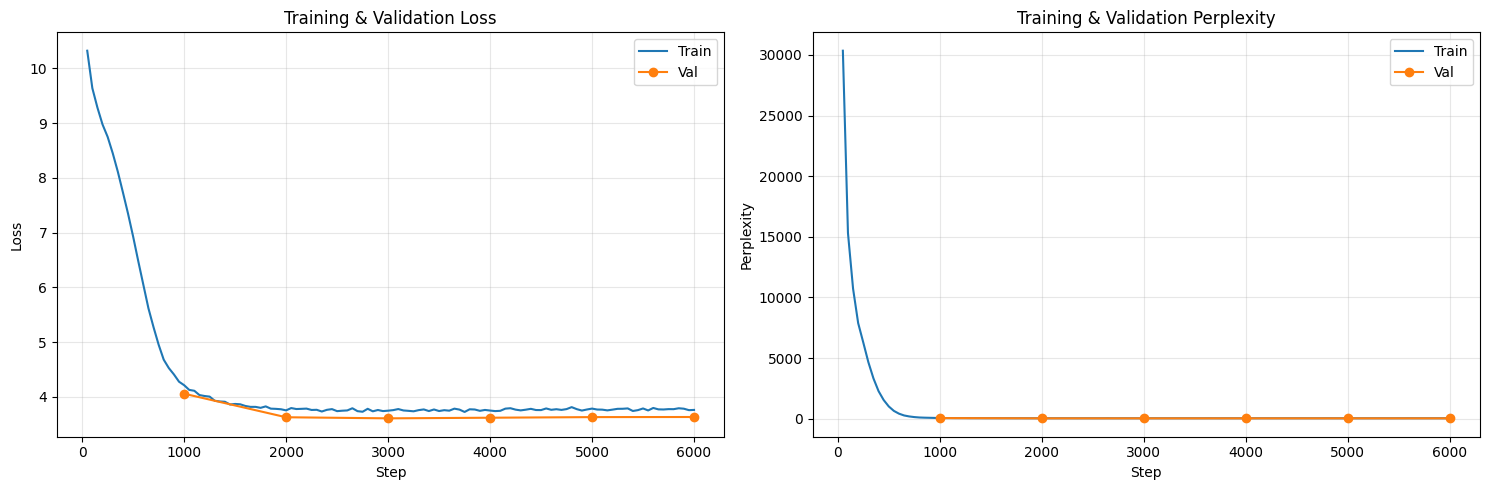

✓ Training curves saved to /content/training_curves.png


In [14]:
# Plot training curves (if tensorboard logs available)
import matplotlib.pyplot as plt
import numpy as np

# Load TensorBoard logs
from tensorboard.backend.event_processing import event_accumulator

log_dir = '/content/logs/gptneo_tinystories'

try:
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()

    # Get metrics
    train_loss = ea.Scalars('train/loss')
    val_loss = ea.Scalars('val/loss')
    train_ppl = ea.Scalars('train/perplexity')
    val_ppl = ea.Scalars('val/perplexity')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    axes[0].plot([x.step for x in train_loss], [x.value for x in train_loss], label='Train')
    axes[0].plot([x.step for x in val_loss], [x.value for x in val_loss], label='Val', marker='o')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Perplexity
    axes[1].plot([x.step for x in train_ppl], [x.value for x in train_ppl], label='Train')
    axes[1].plot([x.step for x in val_ppl], [x.value for x in val_ppl], label='Val', marker='o')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Perplexity')
    axes[1].set_title('Training & Validation Perplexity')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Training curves saved to /content/training_curves.png")

except Exception as e:
    print(f"Could not load TensorBoard logs: {e}")
    print("Run TensorBoard manually to view metrics")

## 9. Save Model to Google Drive

In [15]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create save directory
save_dir = '/content/drive/MyDrive/GPTNeo_TinyStories'
!mkdir -p {save_dir}

# Copy checkpoints
!cp -r /content/checkpoints/gptneo_tinystories {save_dir}/
!cp /content/training_curves.png {save_dir}/
!cp config.json {save_dir}/

print(f"✓ Model saved to Google Drive: {save_dir}")
print("\nFiles saved:")
!ls -lh {save_dir}

Mounted at /content/drive
cp: error writing '/content/drive/MyDrive/GPTNeo_TinyStories/gptneo_tinystories/checkpoint_step_4000.pt': Transport endpoint is not connected
cp: failed to close '/content/drive/MyDrive/GPTNeo_TinyStories/gptneo_tinystories/checkpoint_step_4000.pt': Transport endpoint is not connected
cp: cannot create regular file '/content/drive/MyDrive/GPTNeo_TinyStories/gptneo_tinystories/checkpoint_step_6000.pt': No such file or directory
cp: cannot create regular file '/content/drive/MyDrive/GPTNeo_TinyStories/gptneo_tinystories/final_model.pt': No such file or directory
cp: cannot create regular file '/content/drive/MyDrive/GPTNeo_TinyStories/': No such file or directory
cp: cannot create regular file '/content/drive/MyDrive/GPTNeo_TinyStories/': No such file or directory
✓ Model saved to Google Drive: /content/drive/MyDrive/GPTNeo_TinyStories

Files saved:
ls: cannot access '/content/drive/MyDrive/GPTNeo_TinyStories': No such file or directory


## 10. Summary

### Training Complete! 🎉

**What You Trained:**
- Model: GPTNeo decoder-only (~10M parameters, 4 layers)
- Architecture: 256d hidden, 4 layers, 8 heads
- Dataset: TinyStories (30K samples for fast training)
- Training: 6K steps with BFloat16 on L4
- Learning rate: 5e-5 (stable training)

**Expected Results:**
- Validation PPL: 25-40
- Training time: ~45-60 mins on L4
- Story quality: Coherent children's stories (validated by TinyStories paper)

**Model Comparison:**
- Your 10M model: Fast training, good quality, optimized for iteration
- TinyStories-8M (official): Similar quality, 256d, 8 layers
- TinyStories-28M: Better quality, ~4x longer training
- TinyStories-33M: Best quality, ~5x longer training

**Key Optimizations Applied:**
- Learning rate: 5e-5 (prevents divergence)
- Gradient clip: 0.5 (tighter control)
- Warmup steps: 600 (10% warmup for stability)
- Batch size: 128 (optimized for L4 GPU)
- BFloat16: Native L4 support for 2x speedup

**Next Steps:**
1. Try different prompts in the interactive generator
2. Fine-tune hyperparameters for better results
3. Train longer (increase max_steps) for lower perplexity
4. Try larger model (6-8 layers) if you have more time

**Citation:**
```
Eldan, R., & Li, Y. (2023). TinyStories: How Small Can Language Models Be
and Still Speak Coherent English? arXiv:2305.07759.
```